In [1]:
from Tools.DatasetTools.DatasetOperator import Dataset
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from Tools.DatasetTools import EVCurvesTools as EVtools
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
fullvalidationBS = StructSummaryParser(dataset='validation_data',ForceMakeBS=True).BriefSummary

need to create briefsummary list
reading list of briefsummary


In [4]:
remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',

In [5]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

<Axes: ylabel='Frequency'>

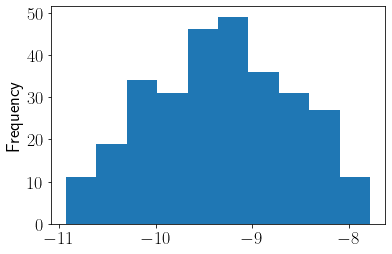

In [6]:
BS['E0'].plot.hist()

In [7]:
validation_samples = fullvalidationBS.index.difference(BS.index)

In [8]:
validation_samples = validation_samples[~validation_samples.str.contains('.FM|sigma')]

In [9]:
len(validation_samples)

53

In [10]:
validationBS = fullvalidationBS.loc[validation_samples]

(array([2., 7., 6., 5., 6., 5., 7., 1., 7., 7.]),
 array([-10.689768 , -10.4192689, -10.1487698,  -9.8782707,  -9.6077716,
         -9.3372725,  -9.0667734,  -8.7962743,  -8.5257752,  -8.2552761,
         -7.984777 ]),
 <BarContainer object of 10 artists>)

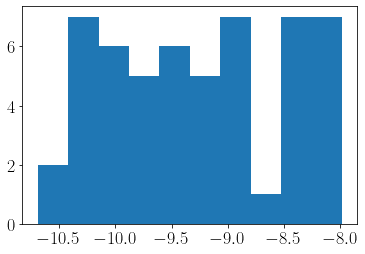

In [11]:
plt.hist(validationBS['E0'])

TODO:
[ ] calculate formation energies for new calculations

In [12]:
validationBS = validationBS[~validationBS.index.str.contains('sigma.[DU]')]

In [13]:
validationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,bulk R-BBABBABBBBB,14.799765 A,-10.155735,252.670511 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,252.670511,14.799765,Fe_pv,Mo_sv,12,41,53
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,bulk R-BBBBBBAABBB,15.127063 A,-9.952566,236.397567 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,236.397567,15.127063,Fe_pv,Mo_sv,12,41,53
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM,bulk P-BBABBBBBBBAB,14.805514 A,-10.243163,255.136017 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,255.136017,14.805514,Fe_pv,Mo_sv,12,44,56
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,bulk R-ABABBABBBBB,14.682019 A,-10.107377,253.012900 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,253.0129,14.682019,Fe_pv,Mo_sv,13,40,53
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,bulk P-BBABBBBABBAB,14.345515 A,-10.077997,259.592633 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,259.592633,14.345515,Fe_pv,Mo_sv,16,40,56
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM,bulk delta-BBBBBBBBABAABA,14.352918 A,-10.078913,259.344782 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,259.344782,14.352918,Fe_pv,Mo_sv,16,40,56
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,bulk R-BBBBBBAAABB,14.604681 A,-9.605003,234.546435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,234.546435,14.604681,Fe_pv,Mo_sv,18,35,53
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,bulk R-ABABAABBBBB,13.911240 A,-9.888909,262.786392 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,262.786392,13.91124,Fe_pv,Mo_sv,19,34,53
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,bulk M-ABBAABBBBBB,13.775506 A,-9.818704,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,263.925712,13.775506,Fe_pv,Mo_sv,20,32,52
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM,bulk R-BAAABABBBBB,13.788419 A,-9.839677,263.889769 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,263.889769,13.788419,Fe_pv,Mo_sv,20,33,53


# Check EVcurves

In [14]:
validation_dataset='validation_data'

In [15]:
fittedcurvesloc = os.path.join(validation_dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(validation_dataset,'evcurves.json' )
goodnessloc = os.path.join(validation_dataset, 'goodness.json')
force = True

In [16]:
EVtools = SourceFileLoader('EVtools', 'Tools/DatasetTools/EVCurvesTools.py').load_module()

In [17]:
test_indexes = validationBS.index[validationBS.index.str.contains('Mo_sv.*P.NM')]

In [18]:
validationBS.loc[test_indexes]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


In [19]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        EV = EVtools.Evcurves(Indexes = validationBS.index, atoms=['Fe','Mo'], dataset = validation_dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = validationBS['deltak'], encuts = validationBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = EVtools.get_goodness(EVcurves, r2tol = 1e-6)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = EVtools.invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = EVtools.get_key_for_curves(EVcurves, 'r2')
    Goodness = EVtools.get_key_for_curves(EVcurves, 'IsGood')
    Fits = EVtools.get_key_for_curves(EVcurves, 'fit')

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [20]:
EVcurves

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

# Recover Predicted values

In [21]:
validationBS.loc[test_indexes]['E0']

Mo_sv56.P.NM   -10.689768
Name: E0, dtype: object

In [22]:
for index, param_curve in EVcurves[test_indexes].items():
    break

In [23]:
Fits[index]

{'xc=PBE-PAW.E=450.dk=0.020': array([-10.68976842, 243.27561015,   4.30669987,  16.23308481])}

In [24]:
for params, curve in param_curve.items():
    break

In [25]:
curve

{'evcurve': {'V': array([16.62275446, 16.54166786, 16.46058125, 16.37949464, 16.29840804,
         16.21732143, 16.13623482, 16.05514821, 15.97406161, 15.892975  ,
         15.81188839]),
  'E': array([-10.68295821, -10.68546036, -10.6874075 , -10.68878161,
         -10.68957179, -10.68975518, -10.68932357, -10.68825768,
         -10.68654286, -10.68415125, -10.68107554])},
 'ev_fit_results': {'E_murn': -10.689768,
  'V_murn': 16.23309,
  'B_murn': 243.233916,
  'Bdev_murn': 4.300952},
 'r2': 0.9999997889117633,
 'fit': array([-10.68976842, 243.27561015,   4.30669987,  16.23308481]),
 'IsGood': True}

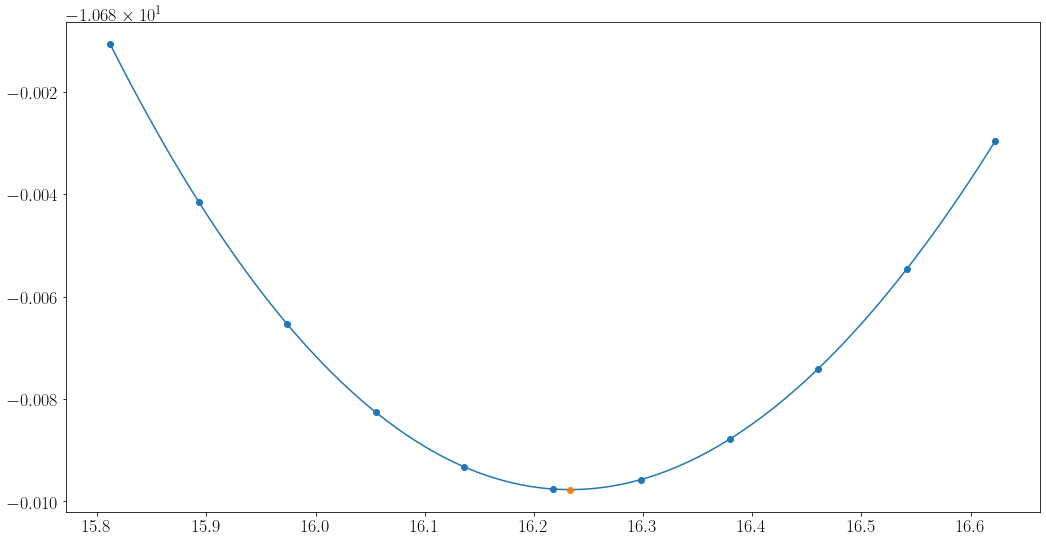

In [26]:
fig, ax = plt.subplots()
EVtools.plot_fitted_curve(curve['evcurve'], Fits[index][params], R2[index][params], ax = ax, fig=fig)
ax.plot([validationBS.loc[index]['V0']], [validationBS.loc[index]['E0']],'o')

In [27]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [28]:
empty_curves = EVcurves[EVcurves.map(lambda c: len(c)==0)].index

In [29]:
EVcurves[empty_curves]

Fe_pv5Mo_sv8.mu-ABBAA.NM    {}
dtype: object

In [30]:
complete_curves = EVcurves.index.difference(empty_curves)

Only take the validationBS with given EV curves

In [31]:
validationBS = validationBS.loc[complete_curves]
EVcurves = EVcurves[complete_curves]
R2 = R2[complete_curves]
Fits = Fits[complete_curves]

# Get dataframes 

In [32]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [33]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [34]:
Better_evcurves = {}

In [35]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_1604061/1452277664.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_1604061/1452277664.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [36]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [37]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [38]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [39]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

Text(0.5, 1.0, '28 Good Samples')

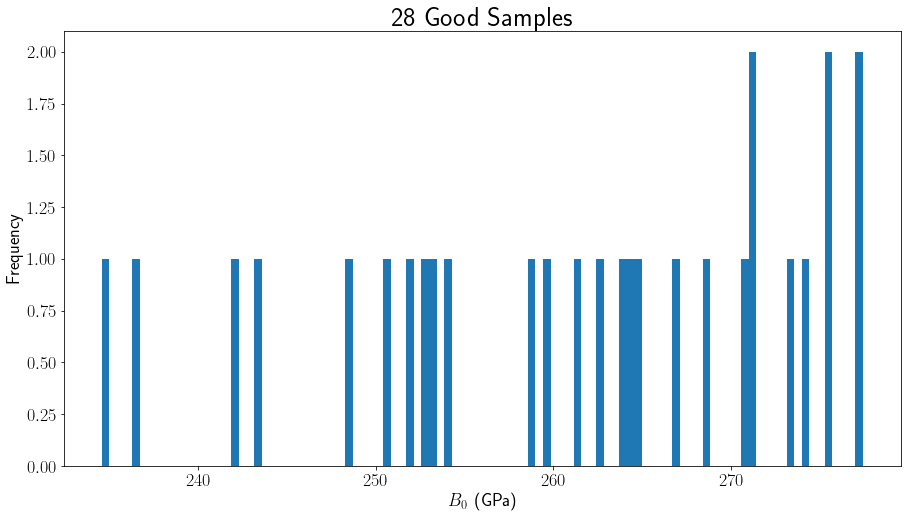

In [40]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [41]:
Better_evcurves_df.shape

(52, 6)

In [42]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [43]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [44]:
indexofbadsamples

Index(['Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM',
       'Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv20Mo_sv33.R-BAAABABBBBB.NM',
       'Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM', 'Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM',
       'Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM', 'Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM',
       'Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM',
       'Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM',
       'Fe_pv40Mo_sv12.M-AAAAAAABABB.NM',
       'Fe_pv40Mo_sv16.delta-AAAAAABBABAAAB.NM',
       'Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM', 'Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM',
       'Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM',
       'Fe_pv48Mo_sv8.delta-AAAAAABAAAAABA.NM',
       'Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM', 'Fe_pv52Mo_sv4.P-AAAABAAAAAAA.NM',
       'Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM', 'Fe_pv56.P.NM',
       'Fe_pv56.delta.NM', 'Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM',
       'Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM'],
      dtype='object')

In [45]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

Text(0.5, 1.0, '28 Good Samples')

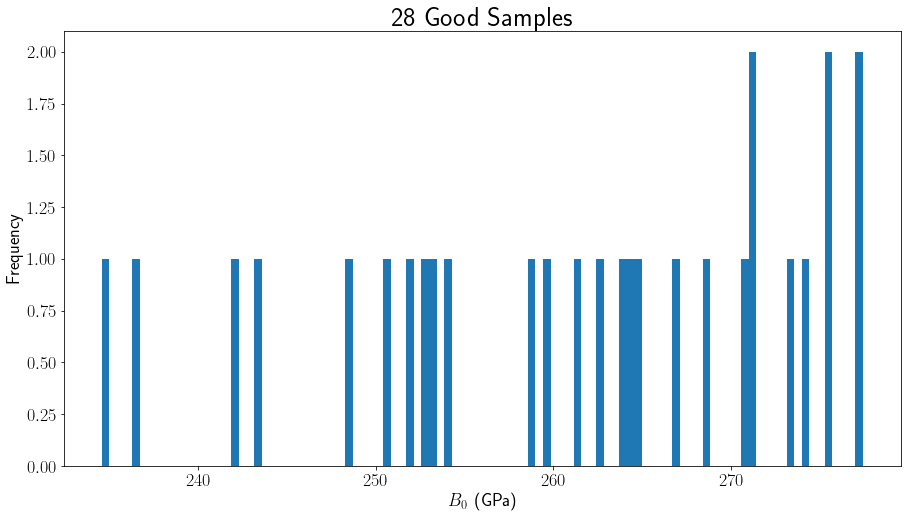

In [46]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [47]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [48]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [49]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

/tmp/ipykernel_1604061/816183106.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f'{NGOOD} good samples')


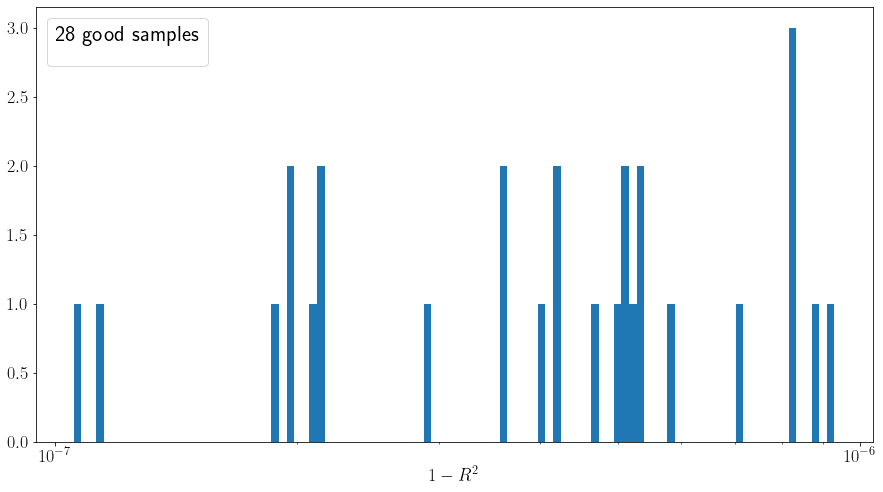

In [50]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

# Differences between fits and available data for bad samples

In [51]:
diff_fit_to_dataset = ((validationBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})

In [52]:
diff_fit_to_dataset['E0'] = ((validationBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [53]:
diff_fit_to_dataset['V0'] = ((validationBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

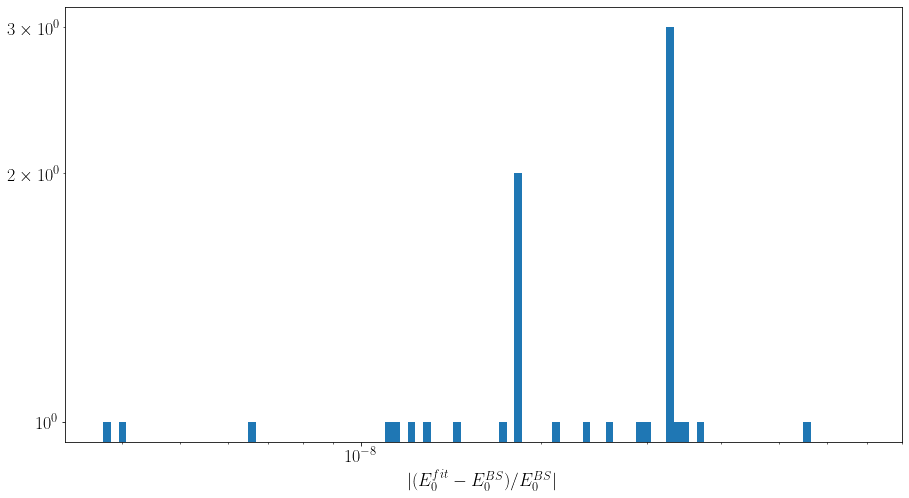

In [54]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

# Try to correct the bad fits by removing points 

In [55]:
from importlib.machinery import SourceFileLoader

In [56]:
len(validationBS)

52

In [57]:
len(indexofgoodsamples)

28

In [58]:
len(indexofbadsamples)

24

In [59]:
GoodBS = validationBS.loc[indexofgoodsamples]

In [60]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-6
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (r2>1-tol) & common_sense_evcurve )
        now_is_good.append( (r2>1-tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

  0%|          | 0/24 [00:00<?, ?it/s]

Tools/DatasetTools/EVCurvesTools.py:233: OptimizeWarning: Covariance of the parameters could not be estimated
  param_result, pcov = curve_fit(birchmurnaghan, reducedv, reducede, param_guess)#,  maxfev=1000*len(try_indexs)) #, ftol=1e-12, xtol = 1e-16)


In [113]:
fixedevcurves

Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

In [114]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [115]:
fixedevcurves_df.shape

(24, 1)

In [116]:
Better_fixedevcurves = {}

In [117]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_1604061/667138312.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_1604061/667138312.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [118]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [119]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [120]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [121]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [122]:
indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [123]:
indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)

In [124]:
indexoffixedbadsamples

Index([], dtype='object')

In [73]:
len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)

52

In [74]:
finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)

In [75]:
finalindexofsamples

Index(['Fe_pv12Mo_sv41.R-BBABBABBBBB.NM', 'Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM',
       'Fe_pv13Mo_sv40.R-ABABBABBBBB.NM', 'Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM',
       'Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM', 'Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM',
       'Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM', 'Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM',
       'Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM',
       'Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM',
       'Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM',
       'Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM',
       'Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAABBABB.NM', 'Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM',
       'Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAAABABB.NM', 'Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM', 'Fe_pv47Mo_sv6.R-AAAAAABBAAA.NM',
       'Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM',
       'Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM',
       'Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM', 'Fe_pv8Mo_sv45.R-BABBBABBBBB.NM',
       'Fe_pv8M

In [76]:
fixedValidationBS = validationBS.loc[finalindexofsamples]

# Fixed quantities

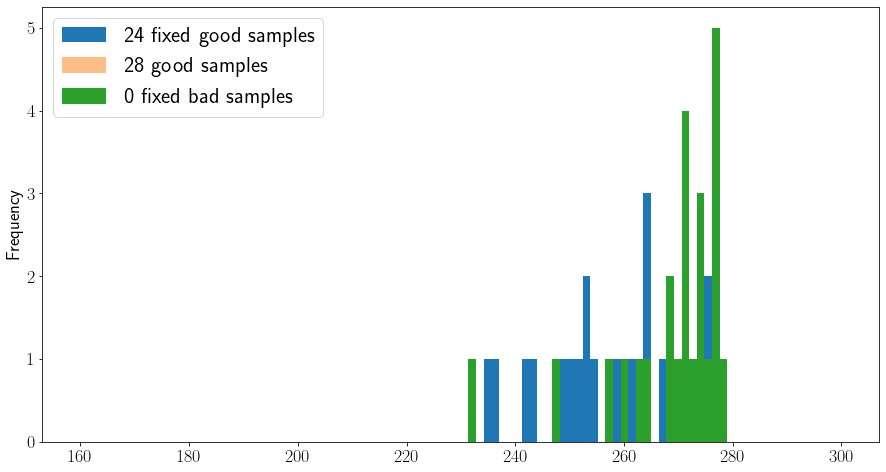

In [77]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

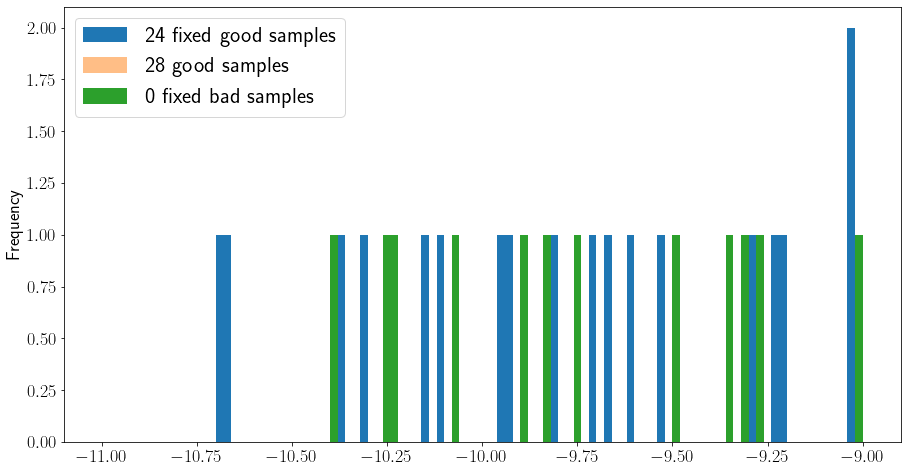

In [78]:
thebins = np.linspace(-11, -9, 101)
ax = ev_fit_results_df.E_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

# redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [79]:
fixedValidationBS['E0'].dropna()

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM          -10.155735
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           -9.952566
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM          -10.107377
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM         -10.077997
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           -9.605003
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           -9.818704
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          -9.926956
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM           -9.673818
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    -9.709519
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          -9.536149
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    -9.349096
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           -9.291793
Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM    -9.211688
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM           -9.223979
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM           -9.028283
Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM    -9.034881
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM           -8.899309
Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM          -8.899489
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM            -8.365961
Fe_pv47Mo_sv

In [80]:
fixedValidationBS.loc[indexoffixedgoodsamples,'E0'] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'V0'] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'B0'] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]
fixedValidationBS.dropna().describe()

,nelem,num_atom_A,num_atom_B,num_atoms
count,52.000000,52.000000,52.000000,52.000000
mean,1.923077,32.192308,22.076923,54.269231
std,0.269069,15.452696,15.330152,1.716305
min,1.000000,6.000000,0.000000,52.000000
25%,2.000000,19.750000,7.500000,53.000000
50%,2.000000,32.000000,20.500000,53.000000
75%,2.000000,47.000000,34.250000,56.000000
max,2.000000,56.000000,48.000000,56.000000


In [81]:
fixedValidationBS.shape

(52, 17)

In [82]:
fixedValidationBS['E0']

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM          -10.155735
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           -9.952566
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM          -10.107377
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM         -10.077997
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           -9.605003
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           -9.818704
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          -9.926956
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM           -9.673818
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    -9.709519
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          -9.536149
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    -9.349096
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           -9.291793
Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM    -9.211688
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM           -9.223979
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM           -9.028283
Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM    -9.034881
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM           -8.899309
Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM          -8.899489
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM            -8.365961
Fe_pv47Mo_sv

In [83]:
import re

In [84]:
def get_phase_from_index(theindex):
    phaseconfig = theindex.split('.')[1]
    phase = phaseconfig.split('-')[0]
    return phase

In [85]:
fixedValidationBS['Phase'] = fixedValidationBS.index.map(get_phase_from_index)

# New data for delta using AMS tools

In [86]:
from ase import Atoms
import pandas as pd

In [87]:

ValidationBS_delta = pd.read_pickle('Fe-Mo/inchulldft/BS.pkl.gzip', compression='gzip')

In [88]:
ValidationBS_delta['ase_atoms'] = ValidationBS_delta['relax_optimized_structure'].map(lambda d: Atoms.fromdict(d))

In [89]:
num_atoms_delta = pd.DataFrame.from_dict(ValidationBS_delta['ase_atoms'].map(lambda d: {s: n for s, n in d.symbols.formula.count().items()}).to_dict(), orient='index').fillna(0)

In [90]:
ValidationBS_delta = pd.concat([ValidationBS_delta, num_atoms_delta], axis=1)

In [91]:
def parse_name(thename):
    splittedname = thename.split('/')
    sample_id = splittedname[-3]
    sample_info = sample_id.split('.')
    return {'Mag': sample_info[-1], '' : sample_info[1], 'Phase' : sample_info[1].split('-')[0], 'sample_id': sample_id}

In [92]:
IDS = pd.DataFrame.from_dict(ValidationBS_delta.name.map(parse_name).to_dict(), orient='index')

In [93]:
ValidationBS_delta = pd.concat([IDS, ValidationBS_delta], axis=1)

In [94]:
ValidationBS_delta.set_index('sample_id', inplace=True)

In [95]:
ValidationBS_delta.columns

Index(['Mag', '', 'Phase', 'name', 'status', 'relax', 'murnaghan',
       'relax_optimized_structure', 'relax_energy', 'relax_forces',
       'relax_volume', 'relax_n_atom', 'relax_stress', 'murnaghan_volume',
       'murnaghan_energy', 'murnaghan_pressure',
       'murnaghan_equilibrium_energy', 'murnaghan_equilibrium_volume',
       'murnaghan_equilibrium_bulk_modulus', 'murnaghan_equilibrium_b_prime',
       'murnaghan_energy_rms', 'ase_atoms', 'Fe', 'Mo'],
      dtype='object')

In [96]:
ValidationBS_delta.rename(columns={'murnaghan_equilibrium_bulk_modulus': 'B0', 'Fe': 'num_atom_A', 'Mo': 'num_atom_B', 'relax_n_atom': 'num_atoms'}, inplace=True)

In [97]:
ValidationBS_delta.columns

Index(['Mag', '', 'Phase', 'name', 'status', 'relax', 'murnaghan',
       'relax_optimized_structure', 'relax_energy', 'relax_forces',
       'relax_volume', 'num_atoms', 'relax_stress', 'murnaghan_volume',
       'murnaghan_energy', 'murnaghan_pressure',
       'murnaghan_equilibrium_energy', 'murnaghan_equilibrium_volume', 'B0',
       'murnaghan_equilibrium_b_prime', 'murnaghan_energy_rms', 'ase_atoms',
       'num_atom_A', 'num_atom_B'],
      dtype='object')

In [98]:
ValidationBS_delta['E0'] = ValidationBS_delta['murnaghan_equilibrium_energy']/ValidationBS_delta['num_atoms']
ValidationBS_delta['V0'] = ValidationBS_delta['murnaghan_equilibrium_volume']/ValidationBS_delta['num_atoms']

In [99]:
ValidationBS_delta.head()['E0']

sample_id
Fe_pv56.delta-AAAAAAAAAAAAAA.NM          -8.012624
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM    -8.468361
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM   -9.908805
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM    -8.260014
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM    -8.482510
Name: E0, dtype: float64

In [100]:
def get_n_atom(natoms):
    if natoms > 0:
        return 1
    return 0

In [101]:
#ValidationBS_delta['atom_A'] =
ValidationBS_delta['atom_A'] = ValidationBS_delta['num_atom_A'].map(lambda a: get_n_atom(a)*'Fe_pv')

In [102]:
#ValidationBS_delta['atom_A'] =
ValidationBS_delta['atom_B'] = ValidationBS_delta['num_atom_B'].map(lambda a: get_n_atom(a)*'Mo_sv')

In [103]:
fixedValidationBS.head()

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Phase
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,bulk R-BBABBABBBBB,14.799765 A,-10.155735,252.670511 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,252.670511,14.799765,Fe_pv,Mo_sv,12,41,53,R
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,bulk R-BBBBBBAABBB,15.127063 A,-9.952566,236.397567 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,236.397567,15.127063,Fe_pv,Mo_sv,12,41,53,R
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,bulk R-ABABBABBBBB,14.682019 A,-10.107377,253.012900 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,253.0129,14.682019,Fe_pv,Mo_sv,13,40,53,R
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,bulk P-BBABBBBABBAB,14.345515 A,-10.077997,259.592633 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,259.592633,14.345515,Fe_pv,Mo_sv,16,40,56,P
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,bulk R-BBBBBBAAABB,14.604681 A,-9.605003,234.546435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,234.546435,14.604681,Fe_pv,Mo_sv,18,35,53,R


In [104]:
FullValidationBS = pd.concat([ValidationBS_delta, fixedValidationBS], axis=0)

In [105]:
FullValidationBS

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,atom_A,atom_B,V,B,fit,xc,encut,deltak,ncrash,nelem
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.00094035, -0.00018561], [0.00...",...,Fe_pv,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539, -0.00019051], [-0.0...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.00081084, 0.00079078, -0.00207556], [-0.0...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM,NM,delta-BABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 26, 26, 26, 26, 4...",-475.020728,"[[-0.00108605, -0.0021022, 0.00095467], [-0.00...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NaN,bulk delta-AABAAAAAAAAAAA,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,10.784047 A,277.152251 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0
Fe_pv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,,10.498095 A,272.113990 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0
Fe_pv56.delta.NM,NaN,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,,10.461103 A,274.874823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM,NaN,bulk R-BBBBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,15.544368 A,246.893484 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0


# Getting Formation Energies

In [106]:
nv = SourceFileLoader('nv', 'Tools/DatasetTools/ValidationSetNormalization.py').load_module()

In [107]:

ground_state_energies ={ ('Fe_pv','NM'): -8.18407186323532,
                       ('Mo_sv', 'NM'): -10.932821158319513,
                      }
# taken from ground_state_energies in notebook 03

In [108]:
normalizer = nv.briefsummary_normalizer(
    ground_states=ground_state_energies, init_bs=FullValidationBS, 
    atomA='Fe', atomB = 'Mo'
)

In [109]:
FullValidationBS['EF'] = normalizer.get_formation_energies()

In [110]:
FullValidationBS[[f'x_{normalizer.atomA}',f'x_{normalizer.atomB}' ]] = normalizer.get_atom_composition()

In [111]:
FullValidationBS.to_pickle('validation_data/FullyCuratedParsedBriefSummary.pkl')

# saving to pickle

In [112]:
FullValidationBS.to_pickle('validation_data/FullyCuratedParsedBriefSummary.pkl')

# Just a peak into the predictions

In [113]:
just_a_prediction = pd.read_csv('Fe-Mo/results/PREDICTION__R__0.7dprojections_0.5os_16.csv', index_col=0)

(array([ 14.,  64., 175., 336., 451., 452., 314., 175.,  49.,  18.]),
 array([-0.03191032,  0.01937849,  0.0706673 ,  0.12195611,  0.17324492,
         0.22453373,  0.27582254,  0.32711135,  0.37840016,  0.42968897,
         0.48097778]),
 <BarContainer object of 10 artists>)

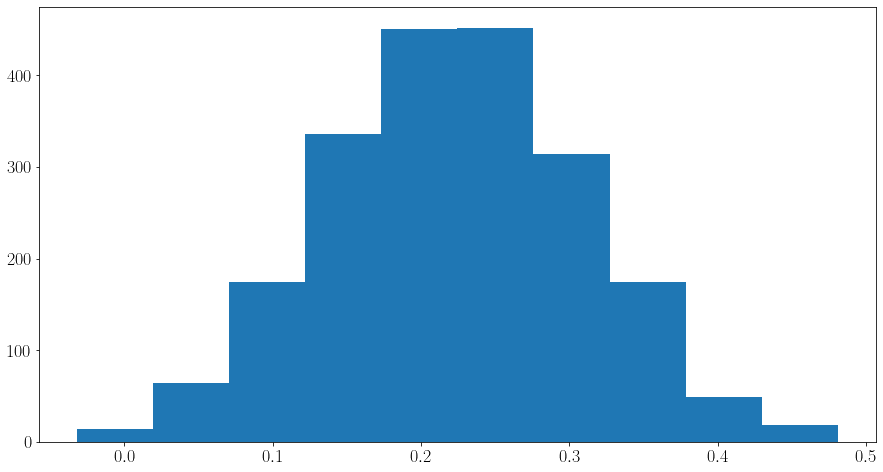

In [114]:
plt.hist(just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'])

In [115]:
validation_R = validationBS.query('index.str.contains("R")')

In [116]:
validated_predictions = validation_R.index.intersection(just_a_prediction.index)

In [117]:
validated_predictions

Index(['Fe_pv12Mo_sv41.R-BBABBABBBBB.NM', 'Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM',
       'Fe_pv13Mo_sv40.R-ABABBABBBBB.NM', 'Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv20Mo_sv33.R-BAAABABBBBB.NM',
       'Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM', 'Fe_pv33Mo_sv20.R-AAAAAABBABB.NM',
       'Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAAABABB.NM', 'Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM',
       'Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM', 'Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM',
       'Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM', 'Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM',
       'Fe_pv8Mo_sv45.R-BABBBABBBBB.NM'],
      dtype='object')

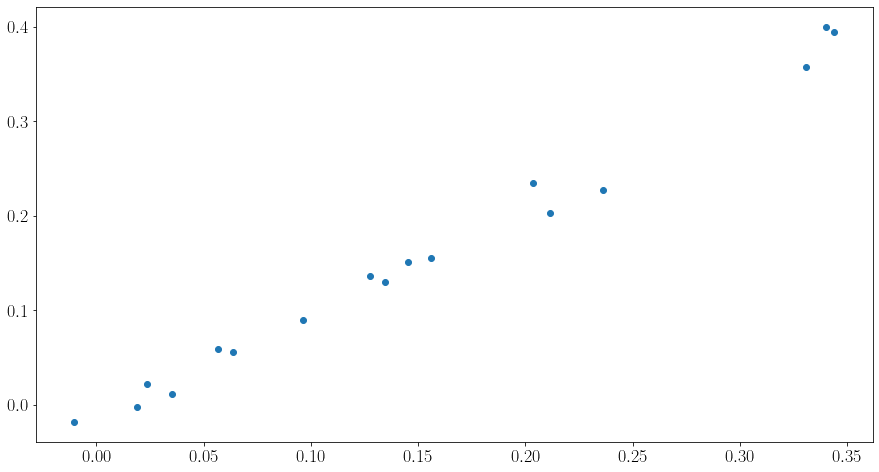

In [118]:
plt.scatter(
    just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'].loc[validated_predictions], 
    FullValidationBS.loc[validated_predictions]['EF']
)

In [119]:
from sklearn.metrics import mean_squared_error

In [120]:
mean_squared_error(
    validationBS['EF'][validated_predictions], just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'][validated_predictions],
    squared=False
)

KeyError: 'EF'